In [ ]:
#Practical 1: Data Wrangling-I
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Load dataset
url="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# # Display first rows
# print(df.head())

# # Check missing values
# print(df.isnull().sum())

# Fill missing values
df['Age'].fillna(df['Age'].mean(), inplace=True)

# Convert categorical to numeric
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# One-hot encoding
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# Normalize data
scaler = MinMaxScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

# Final dataset
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex       Age  SibSp  \
0                            Braund, Mr. Owen Harris    0  0.271174      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  0.472229      1   
2                             Heikkinen, Miss. Laina    1  0.321438      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  0.434531      1   
4                           Allen, Mr. William Henry    0  0.434531      0   

   Parch            Ticket      Fare Cabin  Embarked_Q  Embarked_S  
0      0         A/5 21171  0.014151   NaN       False        True  
1      0          PC 17599  0.139136   C85       False       False  
2      0  STON/O2. 3101282  0.015469   NaN       False        True  
3      0            113803  0.103644  

/tmp/ipykernel_3592/3599120484.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [4]:
# Practical 2: Data Wrangling-II
import pandas as pd
import numpy as np

# Step 1: Create dataset
df = pd.DataFrame({
    'Student_ID': range(1, 101),
    'Marks': np.random.randint(50, 100, 100),
    'Attendance': np.random.uniform(60, 100, 100)
})

# Step 2: Introduce missing values
df.loc[5, 'Marks'] = np.nan
df.loc[10, 'Attendance'] = np.nan

# Step 3: Check missing values
print("Missing Values:\n", df.isnull().sum())

# Step 4: Handle missing values
df['Marks'].fillna(df['Marks'].mean(), inplace=True)
df['Attendance'].fillna(df['Attendance'].mean(), inplace=True)

# Step 5: Detect outliers using IQR
Q1 = df['Marks'].quantile(0.25)
Q3 = df['Marks'].quantile(0.75)
IQR = Q3 - Q1

# Step 6: Remove outliers using clipping
df['Marks'] = np.clip(df['Marks'], Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# Step 7: Apply transformation (log)
df['Marks'] = np.log(df['Marks'])

# Final dataset
print(df.head(10))

Missing Values:
 Student_ID    0
Marks         1
Attendance    1
dtype: int64
   Student_ID     Marks  Attendance
0           1  4.127134   90.360598
1           2  4.488636   69.011385
2           3  4.077537   60.980167
3           4  4.262680   87.308690
4           5  4.025352   69.578875
5           6  4.310460   72.191308
6           7  4.488636   89.989822
7           8  4.007333   78.530707
8           9  4.060443   80.717264
9          10  4.219508   63.544039


/tmp/ipykernel_1615/2892961367.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Marks'].fillna(df['Marks'].mean(), inplace=True)
/tmp/ipykernel_1615/2892961367.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [6]:
# Practical 3: Descriptive Statistics (Iris)
import pandas as pd

# Load dataset directly from URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

columns = ['SepalLength','SepalWidth','PetalLength','PetalWidth','Species']
df = pd.read_csv(url, names=columns)

# Display data
print(df.head())

# Group by species and calculate statistics
stats = df.groupby('Species').describe()

print(stats)

   SepalLength  SepalWidth  PetalLength  PetalWidth      Species
0          5.1         3.5          1.4         0.2  Iris-setosa
1          4.9         3.0          1.4         0.2  Iris-setosa
2          4.7         3.2          1.3         0.2  Iris-setosa
3          4.6         3.1          1.5         0.2  Iris-setosa
4          5.0         3.6          1.4         0.2  Iris-setosa
                SepalLength                                              \
                      count   mean       std  min    25%  50%  75%  max   
Species                                                                   
Iris-setosa            50.0  5.006  0.352490  4.3  4.800  5.0  5.2  5.8   
Iris-versicolor        50.0  5.936  0.516171  4.9  5.600  5.9  6.3  7.0   
Iris-virginica         50.0  6.588  0.635880  4.9  6.225  6.5  6.9  7.9   

                SepalWidth         ... PetalLength      PetalWidth         \
                     count   mean  ...         75%  max      count   mean   
Speci

In [7]:
# Practical 4: Data Analytics-I (Linear Regression)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/housing.csv"

columns = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD',
           'TAX','PTRATIO','B','LSTAT','MEDV']

df = pd.read_csv(url, names=columns)

# Split into features and target
X = df.drop('MEDV', axis=1)
y = df['MEDV']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy (R² score)
print("Model Accuracy:", model.score(X_test, y_test))

Model Accuracy: 0.7421730792206261


In [12]:
# Practical 5: Data Analytics-II (Logistic Regression)
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler

# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Target
df['target'] = data.target

# Features & target
X = df.drop('target', axis=1)
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Error Rate:", 1 - accuracy)

Confusion Matrix:
 [[73  2]
 [ 0 96]]
Accuracy: 0.9883040935672515
Precision: 0.9795918367346939
Recall: 1.0
Error Rate: 0.011695906432748537


In [13]:
# Practical 6: Data Analytics-III (Naïve Bayes Classification)
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

# Load dataset
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Target
df['target'] = data.target

# Features & target
X = df.drop('target', axis=1)
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Model
model = GaussianNB()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("Confusion Matrix:\n", cm)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Error Rate:", 1 - accuracy)

Confusion Matrix:
 [[15  0  0]
 [ 0 17  1]
 [ 0  0 12]]
Accuracy: 0.9777777777777777
Precision: 0.9794871794871796
Recall: 0.9777777777777777
Error Rate: 0.022222222222222254


In [15]:
# Practical 7: Text Analytics

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Download required data
nltk.download('punkt')
nltk.download('punkt_tab')   # ✅ FIX
nltk.download('stopwords')
nltk.download('wordnet')

# Sample text
text = "Text analytics is a crucial step in analyzing unstructured data."

# Tokenization
tokens = word_tokenize(text)
print("Tokens:", tokens)

# Stopwords removal
stop_words = set(stopwords.words('english'))
filtered_tokens = [word for word in tokens if word.lower() not in stop_words]
print("Filtered Tokens:", filtered_tokens)

# Stemming
stemmer = PorterStemmer()
stemmed = [stemmer.stem(word) for word in filtered_tokens]
print("Stemmed Words:", stemmed)

# Lemmatization
lemmatizer = WordNetLemmatizer()
lemmatized = [lemmatizer.lemmatize(word) for word in filtered_tokens]
print("Lemmatized Words:", lemmatized)

# TF-IDF
corpus = [text]
vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform(corpus)

print("TF-IDF Matrix:\n", tfidf.toarray())
print("Feature Names:", vectorizer.get_feature_names_out())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Tokens: ['Text', 'analytics', 'is', 'a', 'crucial', 'step', 'in', 'analyzing', 'unstructured', 'data', '.']
Filtered Tokens: ['Text', 'analytics', 'crucial', 'step', 'analyzing', 'unstructured', 'data', '.']
Stemmed Words: ['text', 'analyt', 'crucial', 'step', 'analyz', 'unstructur', 'data', '.']
Lemmatized Words: ['Text', 'analytics', 'crucial', 'step', 'analyzing', 'unstructured', 'data', '.']
TF-IDF Matrix:
 [[0.33333333 0.33333333 0.33333333 0.33333333 0.33333333 0.33333333
  0.33333333 0.33333333 0.33333333]]
Feature Names: ['analytics' 'analyzing' 'crucial' 'data' 'in' 'is' 'step' 'text'
 'unstructured']


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.3815

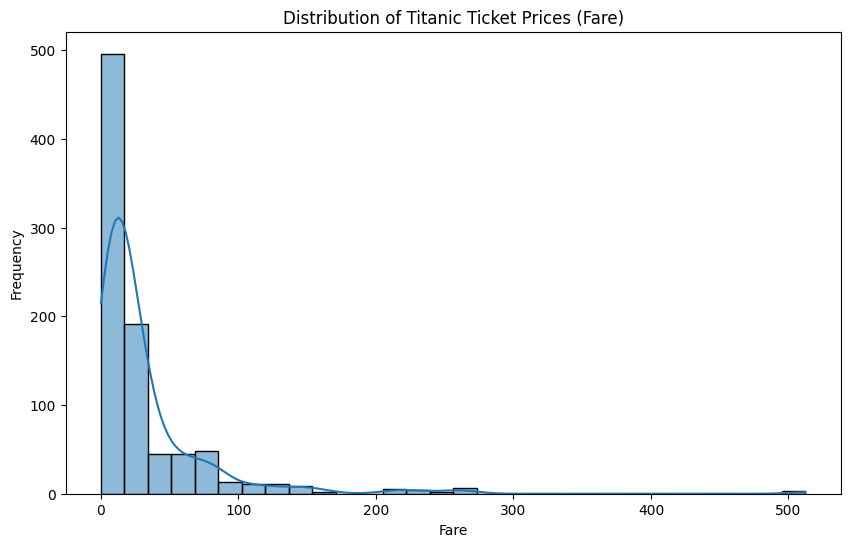

In [16]:
# Practical 8: Data Visualization I

import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset('titanic')

# Display first rows
print(df.head())

# Summary
print(df.describe())

# Histogram of fare
plt.figure(figsize=(10,6))
sns.histplot(df['fare'], kde=True, bins=30)

# Labels
plt.title("Distribution of Titanic Ticket Prices (Fare)")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

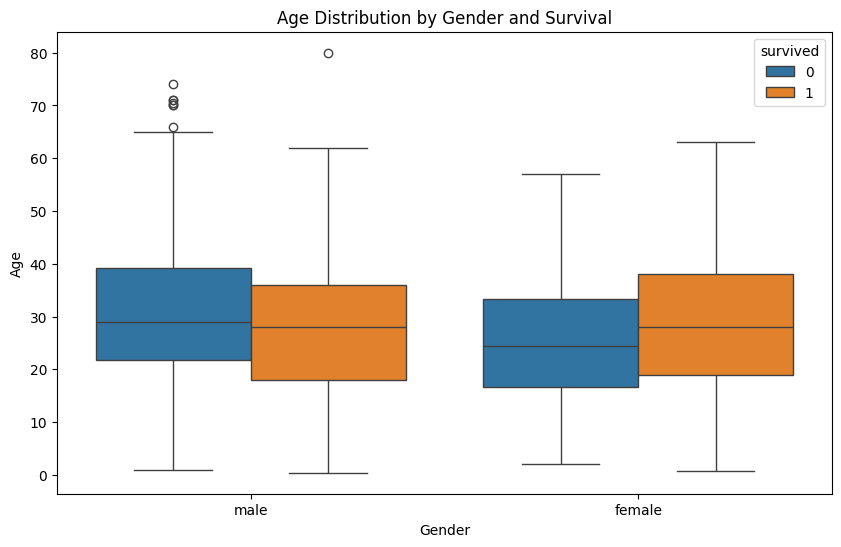

In [17]:
# Practical 9: Data Visualization II

import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset('titanic')

# Box plot
plt.figure(figsize=(10,6))
sns.boxplot(x='sex', y='age', hue='survived', data=df)

# Labels
plt.title("Age Distribution by Gender and Survival")
plt.xlabel("Gender")
plt.ylabel("Age")

plt.show()

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


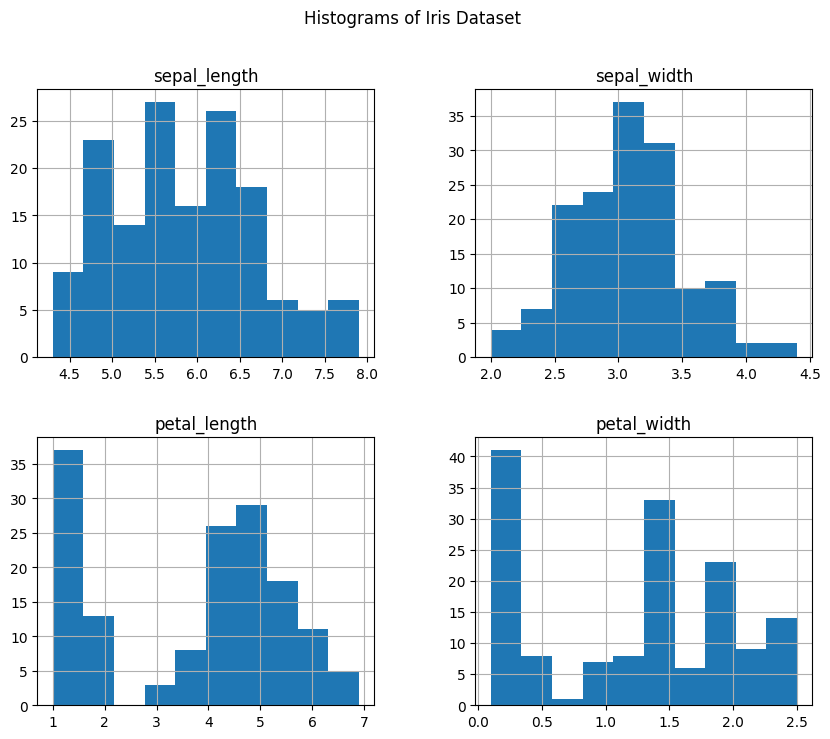

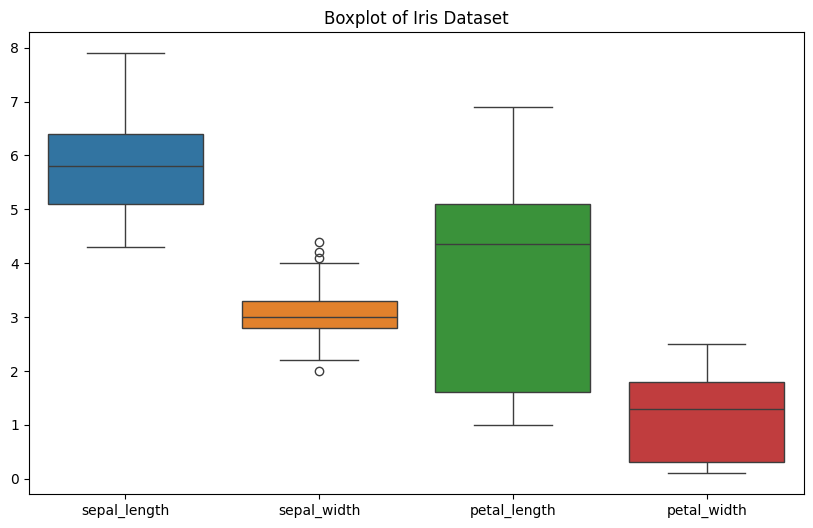

In [18]:
# Practical 10: Data Visualization III

import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset('iris')

# Display dataset
print(df.head())

# Feature types
print(df.dtypes)

# Histograms for all features
df.hist(figsize=(10,8))
plt.suptitle("Histograms of Iris Dataset")
plt.show()

# Boxplot for all features
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title("Boxplot of Iris Dataset")
plt.show()